In [1]:
import copy
import glob
# import json
import os
import pickle
import time
import random

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from osgeo import gdal
import rasterio
# import pandas as pd
# import pickle
# import statistics
# import utm

from koger_detection.landscape.drone_movement import get_warps

import orthocount.mapping_functions as mf
import orthocount.counting as counting
plt.style.use('dark_background')

In [2]:
video_name = "bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D"
video_folder = "/mnt/f/porcupine-island-2023/drone-flights"
video_file = os.path.join(video_folder, video_name + ".MP4")

anchor_folder = os.path.join("/mnt/c/Users/benko/Documents/local_projects/bears", f"{video_name}")

anchor_files = sorted(
    glob.glob(os.path.join(anchor_folder, "*.[jJ][pP][gG]"))
)
print(len(anchor_files), "anchor files found.")
print(os.path.exists(video_file))

warps = get_warps(video_file, anchor_folder, max_pseudo_anchors=2, inlier_threshold=100, 
                  ransac_reproj_threshold=5)


50 anchor files found.
True
0 frames processed.
1000 frames processed.
2000 frames processed.
num pseudo anchors used in 0: 1
num pseudo anchors used in 1: 1
3000 frames processed.
num pseudo anchors used in 2: 1
num pseudo anchors used in 3: 1
num pseudo anchors used in 4: 1
num pseudo anchors used in 5: 1
num pseudo anchors used in 6: 1
num pseudo anchors used in 7: 1
num pseudo anchors used in 8: 1
num pseudo anchors used in 9: 1
num pseudo anchors used in 10: 2
num pseudo anchors used in 11: 1
num pseudo anchors used in 12: 1
num pseudo anchors used in 13: 1
num pseudo anchors used in 14: 1
num pseudo anchors used in 15: 1
num pseudo anchors used in 16: 1
num pseudo anchors used in 17: 1
num pseudo anchors used in 18: 1
num pseudo anchors used in 19: 1
num pseudo anchors used in 20: 1
num pseudo anchors used in 21: 2
num pseudo anchors used in 22: 1
num pseudo anchors used in 23: 2
num pseudo anchors used in 24: 1
num pseudo anchors used in 25: 1
num pseudo anchors used in 26: 1
nu

In [ ]:
warps

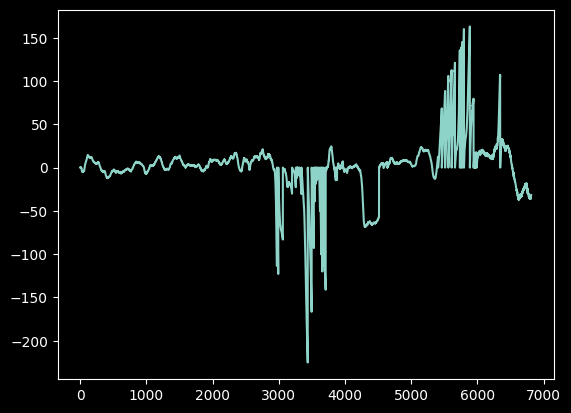

In [3]:
x = [w['warp'][0, -1] for w in warps.values()]
plt.plot(x)

In [3]:
anchor_num = 5 # 10
last_warp = None
for frame_num, ex_warp in warps.items():
    if ex_warp['anchor_num'] == anchor_num:
        break
    last_warp = ex_warp
print(frame_num, ex_warp)
print(frame_num, last_warp)

3248 {'warp': array([[ 9.99913176e-01, -5.56767558e-05,  1.07565102e+01],
       [ 5.56767558e-05,  9.99913176e-01,  4.31509085e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]), 'anchor_num': 5}
3248 {'warp': array([[ 1.00062442e+00, -3.41612738e-04, -1.28277798e+01],
       [ 3.41612738e-04,  1.00062442e+00, -8.99077609e+01],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]), 'anchor_num': 4}


Text(0.5, 1.0, 'No Correction')

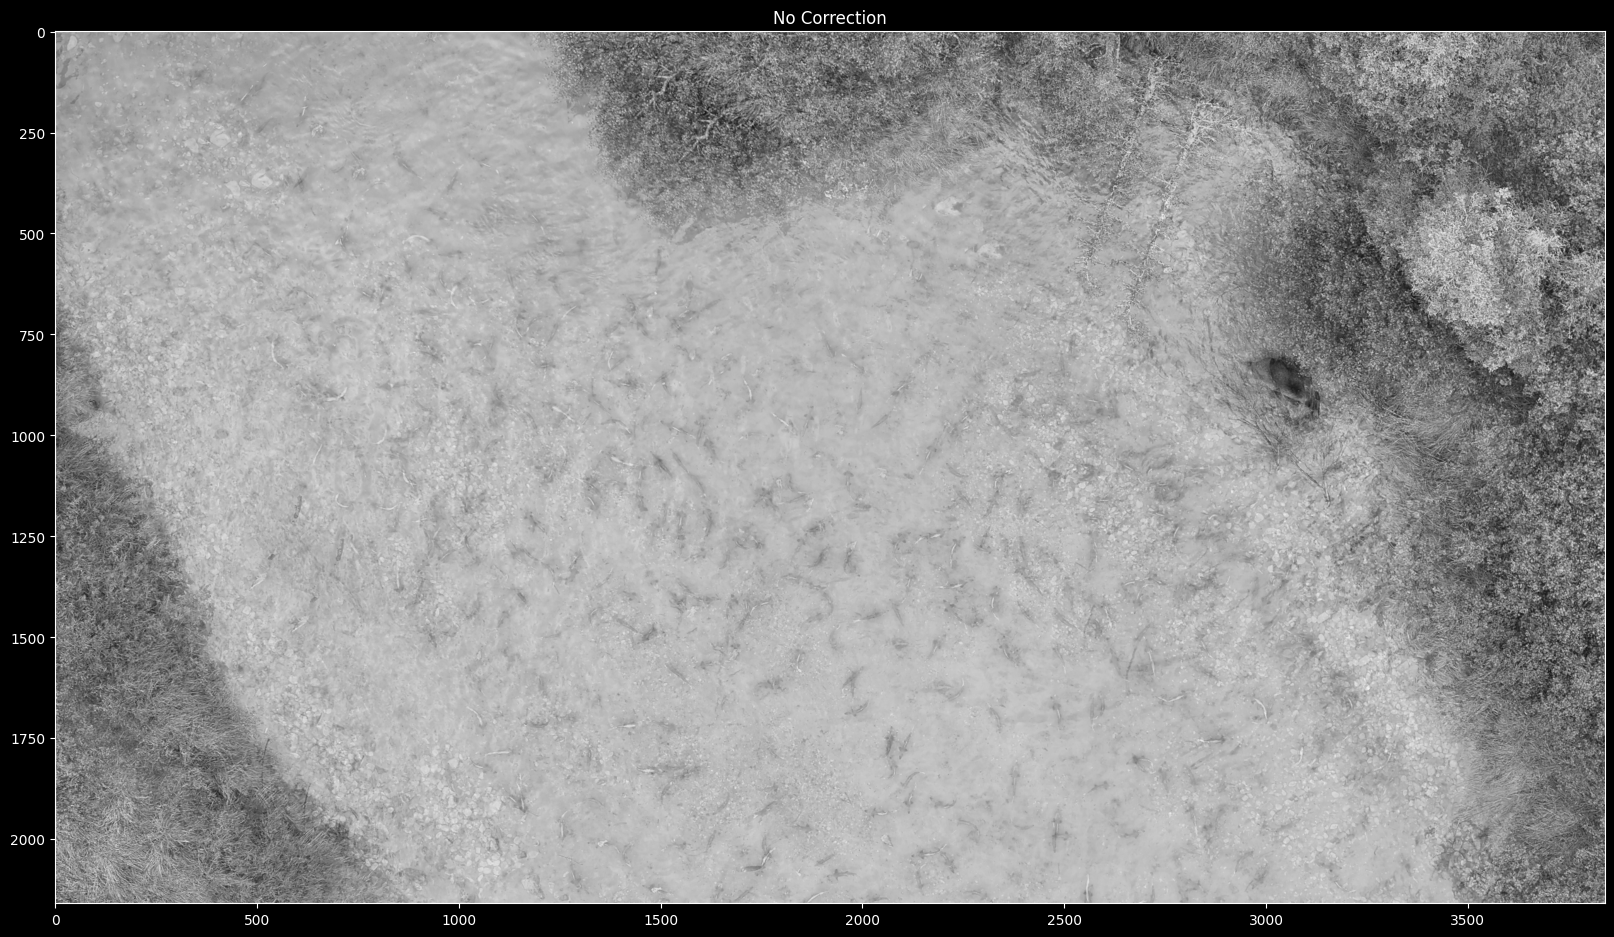

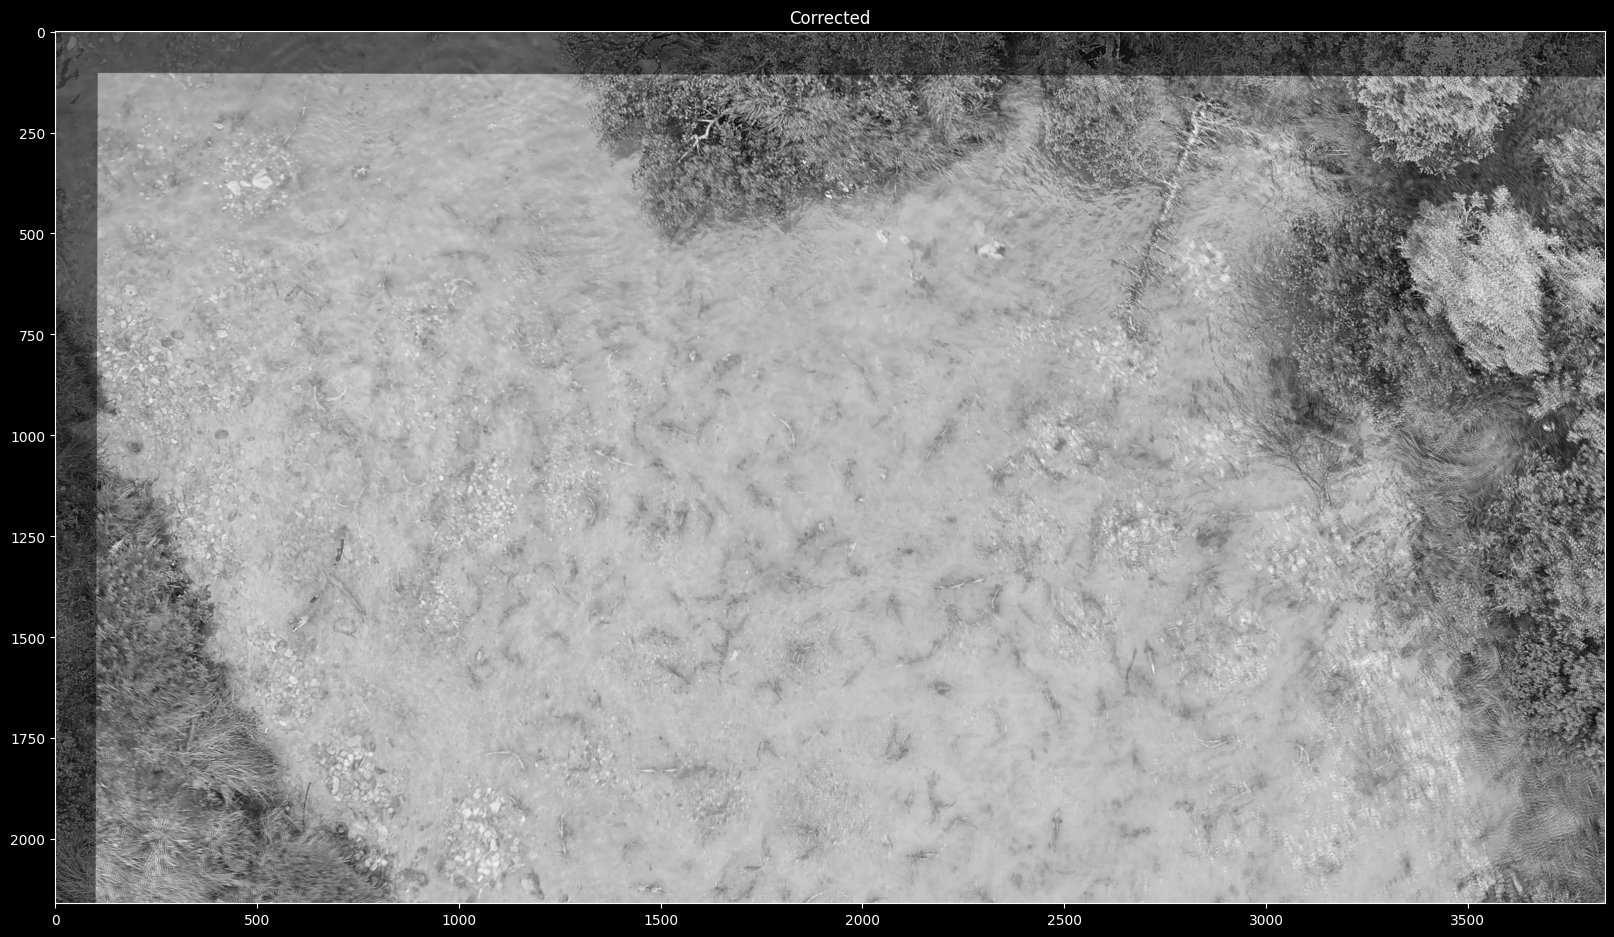

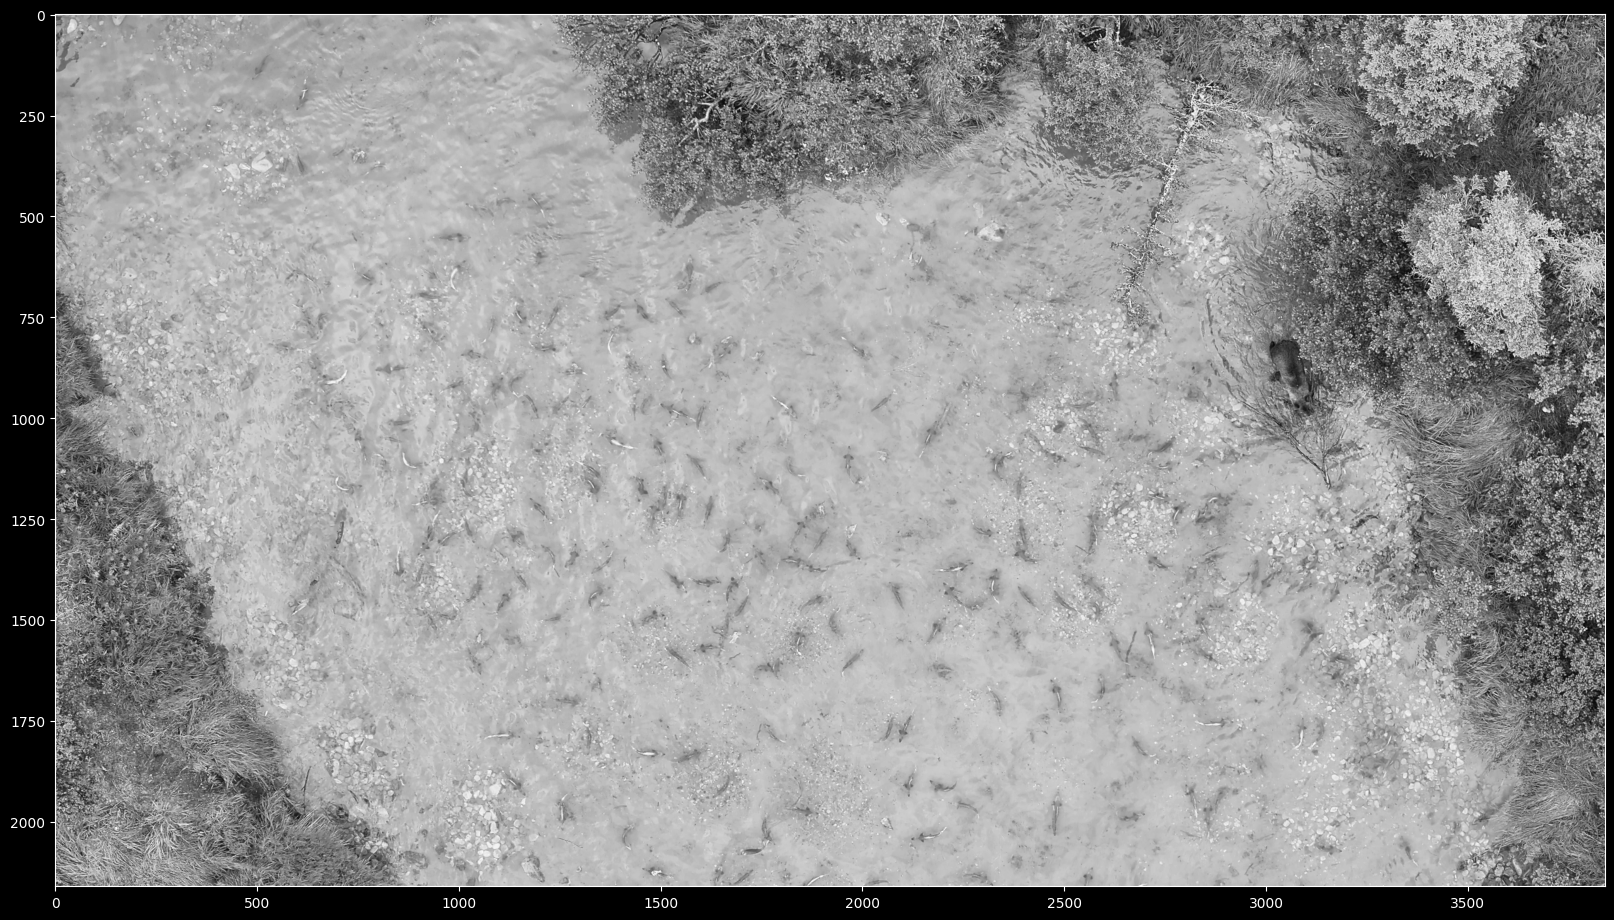

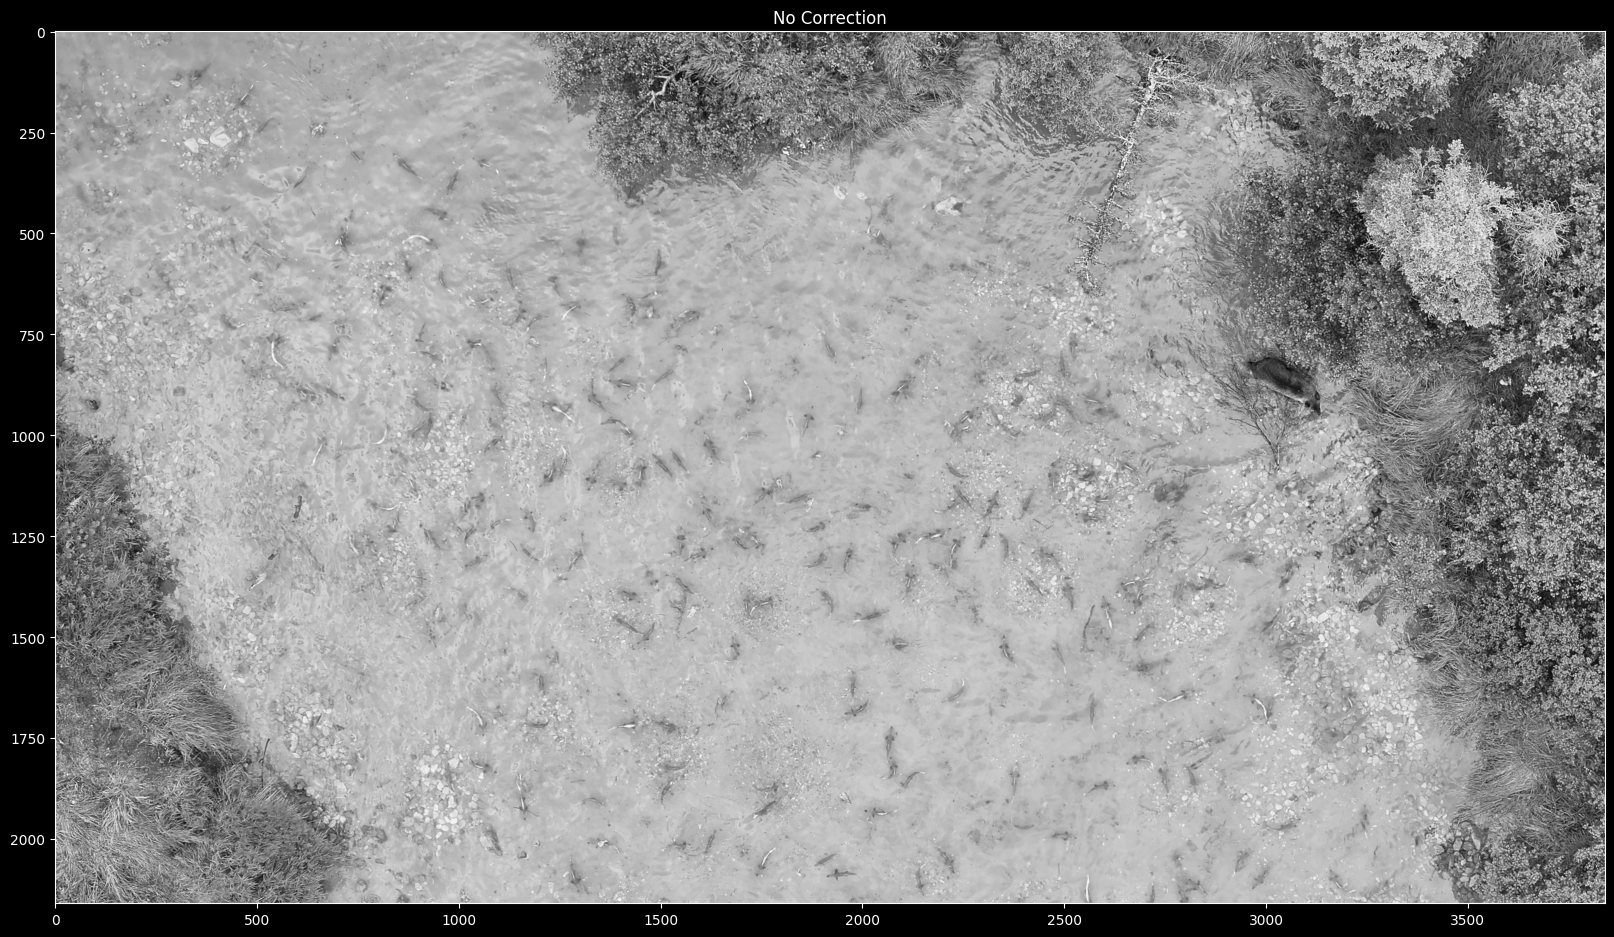

In [14]:
anchor_num = 35 # 10
last_warp = None
for frame_num, ex_warp in warps.items():
    if ex_warp['anchor_num'] == anchor_num:
        break
    last_warp = ex_warp

anchor_files = sorted(
        glob.glob(os.path.join(anchor_folder, "*.[jJ][pP][gG]"))
    )
import matplotlib.pyplot as plt
a_ind = anchor_num-1

frame0_raw = cv2.imread(anchor_files[a_ind])
frame0_gray = cv2.cvtColor(frame0_raw, cv2.COLOR_BGR2GRAY)

frame1_raw = cv2.imread(anchor_files[a_ind+1])
frame1_gray = cv2.cvtColor(frame1_raw, cv2.COLOR_BGR2GRAY)

warp = warps[frame_num-1]['warp']

warped_image = cv2.warpAffine(frame1_gray, M=warp[:2], 
                              dsize=(frame0_raw.shape[1], frame0_raw.shape[0]))

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(frame1_gray, alpha=.5, cmap='gray')
plt.title("No Correction")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.imshow(warped_image, alpha=.5, cmap='gray')
plt.title("Corrected")

plt.figure(figsize=(20,20))
plt.imshow(frame0_gray, cmap='gray', )
plt.figure(figsize=(20,20))
plt.imshow(frame1_gray, alpha=1.0, cmap='gray')
plt.title("No Correction")

In [6]:
# Project name assosiated with the saved pix4d files

pix4d_project_name = f"bear_big2a_2023_08_16_koger_01_01_DJI_20230816175814_0573_D"

pix4d_folder = os.path.join("/mnt/c/Users/benko/Documents/pix4d/bears", pix4d_project_name)
pix4d_info = mf.get_pix4d_info(pix4d_folder, pix4d_project_name, pmatrix_sort='simple',
                               load_ortho=True)
# These are the pmatrixes for all images across all days at that pond
pix4d_info['raw_pmatrices'] = copy.deepcopy(pix4d_info['pmatrices'])

In [69]:
tracks_folder = os.path.join("/mnt/c/Users/benko/Documents/local_projects/bears/videos")
tracks_salmon = pickle.load(open(os.path.join(tracks_folder, f'{video_name}-tracks.pkl'), 'rb'))
tracks_bear = pickle.load(open(os.path.join(tracks_folder, f'{video_name}-tracks-class-1.pkl'), 'rb'))

In [28]:
for track in tracks.items():
    print(track)
    break

(17039, {1: array([1810., 1600.,   93.,   46.]), 2: array([1807.43741037, 1598.26446281,   99.86071646,   49.47107438]), 3: array([1809.37495745, 1596.4527588 ,  103.84076148,   51.5836236 ]), 4: array([1813.50035525, 1597.33922038,  100.46046624,   50.03008904]), 5: array([1816.86887353, 1599.20092863,   98.81586325,   49.37864647]), 6: array([1821.51862013, 1601.26780674,   96.75069118,   48.42725842]), 7: array([1824.8740408 , 1604.08629806,   95.8528046 ,   48.09243328]), 8: array([1830.73577595, 1606.43143605,   92.88622783,   46.5936401 ]), 9: array([1836.40427667, 1608.60719818,   89.28957532,   44.67390272]), 10: array([1841.59184579, 1611.40210953,   83.46566458,   41.2288528 ]), 11: array([1852.08316274, 1619.37676681,   70.79216881,   33.67934761]), 12: array([1858.1086222 , 1625.76690533,   62.56869106,   28.13231753]), 13: array([1860.81414726, 1629.0266017 ,   60.96607566,   25.85550315]), 14: array([1862.06947929, 1630.58755514,   63.09790667,   25.30223749]), 15: array(

In [26]:
tracks[21123][6200]

array([1864.64760589,    2.31798707,   61.83434508,   66.89831923])

In [12]:
# Parameters for projecting points from video into the 3D map
correct_threshold = 0.1 # Acceptable distance from target height above ground
max_guesses = 50 # Max tries to find a point along projection ray within correct_threshold  
initial_mu = 30 # Initial distance along projection ray to start searching
object_height = .25 # Target animal height above ground 

In [13]:
import orthocount.mapping_functions as mf

In [73]:
demo_image = Image.open(anchor_files[0])
image_height = demo_image.height
image_width = demo_image.width

max_frames = max(warps.keys())

raster_tracks = {}
raster_tracks_bear = {}

mu_est = 40
for frame_num in range(max_frames):
    

    anchor_index = warps[frame_num]['anchor_num']

    pmatrix_dict = mf.correct_pmatrix(pix4d_info['pmatrices'][anchor_index], 
                                    warps[frame_num]['warp'], mu_est)
    
    # pmatrix_dict = pix4d_info['pmatrices'][anchor_index]

    rotation_matrix = copy.copy(warps[frame_num]['warp'][:2, :2])

    for track_id, track in tracks_salmon.items():
        if frame_num not in track:
            continue
        box = track[frame_num]
        
        x = box[0] + int(box[2] / 2)
        y = box[1] + int(box[3] / 2)
            
        track_uv_rot = np.matmul(rotation_matrix, np.array([x, y]))
        # track_uv_rot = np.array([x, y])
        x_utm, y_utm, _, mu_est, _ = mf.from_image_to_map(track_uv_rot, mu_est, 
                                                    pmatrix_dict, pix4d_info, 
                                                    max_guesses, correct_threshold, 
                                                    object_height)
        x_raster, y_raster = mf.utm_to_raster(x_utm, y_utm, pix4d_info, image_scale=1.0)
        if track_id not in raster_tracks:
            raster_tracks[track_id] = {}
        raster_tracks[track_id][frame_num] = (x_raster, y_raster)

    for track_id, track in tracks_bear.items():
        if frame_num not in track:
            continue
        box = track[frame_num]
        
        x = box[0] + int(box[2] / 2)
        y = box[1] + int(box[3] / 2)
            
        track_uv_rot = np.matmul(rotation_matrix, np.array([x, y]))
        # track_uv_rot = np.array([x, y])
        x_utm, y_utm, _, mu_est, _ = mf.from_image_to_map(track_uv_rot, mu_est, 
                                                    pmatrix_dict, pix4d_info, 
                                                    max_guesses, correct_threshold, 
                                                    object_height)
        x_raster, y_raster = mf.utm_to_raster(x_utm, y_utm, pix4d_info, image_scale=1.0)
        if track_id not in raster_tracks_bear:
            raster_tracks_bear[track_id] = {}
        raster_tracks_bear[track_id][frame_num] = (x_raster, y_raster)

# center_track = np.array(center_track)

couldn't find precise point 304.8092498791028 309.9703947220885 0.2397912989638371
couldn't find precise point 306.0245386707025 309.51086462488155 -0.24898564185969008
couldn't find precise point 305.99855788307326 310.24760764181735 0.1240533651282476


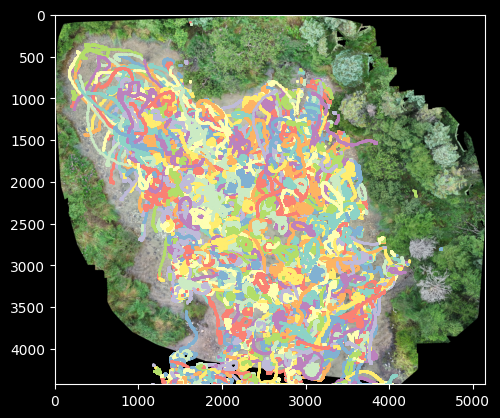

In [34]:
plt.imshow(pix4d_info['ortho'])
for track in raster_tracks.values():
    track_points = np.array(list(track.values()))
    plt.scatter(track_points[:,0], track_points[:,1], s=1, alpha=1)

In [71]:
from vidgear.gears import WriteGear
import matplotlib as mpl

In [74]:
create_video = True

cmap = mpl.colormaps['tab20']
colors = [(np.array(c) * 255) for c in cmap.colors]

out_folder = "/mnt/c/Users/benko/Documents/local_projects/bears/videos"
out_name = video_name + "-landscape.mp4"

if create_video:
    output_params = {"-input_framerate": 30,
                # "-pix_fmt": "yuv420p",
                # "-maxrate":"2500k","-bufsize":"2500k"
                }
    writer = WriteGear(output=os.path.join(out_folder, out_name),
                    **output_params) 
    
video_scale = 0.25
    
background = cv2.resize(pix4d_info['ortho'], 
                        (int(pix4d_info['ortho'].shape[1] * video_scale), 
                         int(pix4d_info['ortho'].shape[0] * video_scale))
                        )


if create_video:
    t0 = time.time()
    for frame_num in range(len(warps)):
        frame = np.copy(background)
        for track_id, track in raster_tracks.items():
            if frame_num not in track:
                continue
            x, y = track[frame_num]
            color = colors[track_id % len(colors)]
            cv2.circle(frame, [int(x * video_scale), int(y * video_scale)], 3, color, -1)

        for track_id, track in raster_tracks_bear.items():
            if frame_num not in track:
                continue
            x, y = track[frame_num]
            color = colors[track_id % len(colors)]
            cv2.circle(frame, [int(x * video_scale), int(y * video_scale)], 6, [255, 0, 0], -1)

        writer.write(frame[:-50], rgb_mode=True)
        
        # if frame_num > 150:
        #     break 

if create_video: 
    writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {frame_num / total_time}", f"{frame_num} frames processed.")

16:40:17 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


42.79985308647156 fps: 159.1594248288011 6812 frames processed.


In [60]:
writer.close()

In [54]:
np.array(background.shape) * .25

array([276.25, 321.75,   0.75])

In [ ]:
def get_frame_pos_to_utm(frame_pos, anchor_index, segment_step, 
                         segment_movements_list, pmatrix_dict, pix4d, 
                         mu_est, max_guesses, correct_threshold, image_shape, 
                         bias=None, object_height=1):

    """ Calculate utm positions for every track at obs_ind.
    
    Return num tracks by two array. nan if track isn't present
    
    Args:
        frame_pos: frame coordinates (uv top left origin)
        anchor_index: groundtruth index
        segment_step: segment ind
        segment_movements_list: arrays relating frame to anchor
        pmatrix_dict: must contain inv_mmatrix (inverse of the first three columns of pmatrix)
            and p4 (fourth column of pmatrix). Corrected for this frame
            from the last anchor frame
        pix4d: dictionary of with keys:
            offset: camera coordinates offset
            elevation_r: elevation raster plot of map area
            pixel_width: pixel width of pixels in elevation raster in utm units
            pixel_height: like pixel width
            x_origin: origin of elevation raster in utm units
            y_origin: like x_origin
        mu_est: where to start looking for ground
        max_guesses: how many iterations to search along projection ray before returning estimate
        correct_threshold: if the distance between the point on the projection ray and the ground is 
                           within this threshold stop seraching and return point
        bias: how much to modify utm points (known error between segments for instance)
        object_height: expected height of object above ground
    """
    
    if anchor_index >= len(segment_movements_list):
        # Last frame
        if anchor_index < len(pix4d['pmatrices']):
            movement_matrix = np.eye(3)
        else:
            print("Error, gt_index too high, returning False, False")
            return False, False
    else:
        # Translation from last ground truth
        movement_matrix = segment_movements_list[anchor_index][segment_step]
    
    pmatrix_dict = correct_pmatrix(pix4d['pmatrices'][anchor_index], 
                                   movement_matrix, mu_est)

    rotation_matrix = copy.copy(movement_matrix[:2, :2])
    
    if bias is None:
        bias = np.zeros((len(tracks), 2), dtype=float)
    

    track_uv_rot = np.matmul(rotation_matrix, frame_pos)
    x_utm, y_utm, _, mu, _ = from_image_to_map(track_uv_rot, mu_est, 
                                               pmatrix_dict, pix4d, 
                                               max_guesses, correct_threshold, 
                                               object_height)

    utm = [x_utm, y_utm] + bias[track_ind]
    
    return utm, mu

In [42]:
anchor_num = warps[frame_num]['anchor_num']
pmatrix_info = pix4d_info['raw_pmatrices'][anchor_num]

In [ ]:
for track_id, track in tracks.items():
    if ind in track:
        box = track[ind]

In [ ]:
demo_image = Image.open(anchor_files[0])
image_height = demo_image.height
image_width = demo_image.width



fish_counts = []
dates = []
heat_maps = []
raw_fish_count = 0

for map_date in range(16, 17):
    print(f"date: {map_date}")
    counting.set_pmatricies_for_date(pix4d_info, map_date, frame_files)
    if len(pix4d_info['pmatrices']) == 0:
        print(f"No pmatricies for {map_date}")
        continue
    dates.append(map_date)
    # create_detection_normalization_layer()
    locs = counting.project_all_detections_to_map(
        pix4d_info, detection_folder, min_detection_confidence, initial_mu, 
        max_guesses, correct_threshold, object_height
    )
    
    # Size of one channel of ortho
    # uint8 to decrease memory (can't handle more than 255 cameras recording pixel!)
    camera_count_map = np.zeros_like(orthomap[..., 0], dtype=np.uint8)
    # For each camera, we are going to estimate what the camera sees in the landscape 
    # with the polygon defined by a number of points along the edge of the camera image
    # projected into the scene. If flat earth, only need the corners. On 3d earth this
    # is an aproximation that is better or worse depending on the ground structure. 
    # Can add more points along edge to get a better aproximation.
    edge_coords = counting.get_image_edge_coordinates(image_width, image_height, points_per_edge=50)
    
    for pmatrix_dict in pix4d_info['pmatrices'][:]:
        view_mask = counting.get_camera_view_mask(pmatrix_dict, edge_coords, camera_count_map*0, 
                                         pix4d_info, ortho_info, z_guess=initial_mu, max_guesses=max_guesses, 
                                         correct_threshold=correct_threshold, 
                                         object_height=object_height)
        camera_count_map += view_mask
    
    fish_heatmap = np.zeros_like(orthomap[..., 0], dtype=float)
    
    for im_locs in locs:
        for loc in im_locs:
            raster_loc = mf.utm_to_raster(*loc[:2], ortho_info)
            raster_loc = counting.constrain_point_to_ortho(raster_loc, orthomap)
            normalization = camera_count_map[raster_loc[1], raster_loc[0]]
            if normalization == 0:
                print(raster_loc)
            fish_heatmap[raster_loc[1], raster_loc[0]] = 1 / normalization
            raw_fish_count += 1
    
    fish_heatmap = cv2.GaussianBlur(fish_heatmap, (201, 201), 30)
    heat_maps.append(fish_heatmap)
    
    fish_counts.append(np.sum(fish_heatmap))
print(raw_fish_count)
print(fish_counts[0])